# PART0 NAM stats
SNP information, etc

In [1]:
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import seaborn as sns

# Marker number / density

In [2]:
parent_list = pd.read_csv("../data/family_list.csv").family.unique()

In [ ]:
# extract marker genotypes of parental lines
parent_genotype = pd.DataFrame()
for i in tqdm(range(1,13)):
    tmp_chr = "chr{}".format(str(i).zfill(2))
    genotype = pd.read_csv("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_{}.txt.gz".format(tmp_chr), sep="\t")
    columns = ["chr", "pos"]
    columns.extend(parent_list)
    parent_genotype = pd.concat([parent_genotype, genotype.loc[:, columns]], axis=0)
with open('../data/PART0_NAM_stats/parent_genotype.pic.bin', 'wb') as p:
    pickle.dump(parent_genotype, p)

In [3]:
# calculate the number of SNPs for each parental line
with open('../data/PART0_NAM_stats/parent_genotype.pic.bin', 'rb') as p:
    parent_genotype = pickle.load(p)
parent_marker_stats = pd.DataFrame((parent_genotype.iloc[:, 2:] == 2).sum())
parent_marker_stats.columns = ["Number_of_SNPs"]
parent_marker_stats

,Number_of_SNPs
N01_KASALATH,1044152
N03_KEIBOBA,968853
N04_SHONI,1020967
N05_TUPA121-3,979144
N06_SURJAMUKHI,1005188
N07_RATUL,1011731
N08_BADARI_DHAN,1041788
N09_KALUHEENATI,971821
N10_JAGUARY,210586
N11_REXMONT,309689


# Number of Homozygous, Heterozygous markers

In [4]:
# calculate the number of Homo/Hetero genotype markers for each RIL
marker_genotype_counts = pd.DataFrame()
for i in tqdm(range(1,13)):
    tmp_chr = "chr{}".format(str(i).zfill(2))
    genotype = pd.read_csv("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_{}.txt.gz".format(tmp_chr), sep="\t")
    chr_marker_genotype_counts = pd.DataFrame()
    for parent in parent_list:
        pop = parent[:3]
        columns = ["chr", "pos"]
        columns.extend(genotype.columns[genotype.columns.str.contains(pop)])
        fam_genotype = genotype.loc[genotype[parent] == 2, columns]
        chr_fam_marker_genotype_counts = pd.concat([(fam_genotype.iloc[:, 3:] == 2).sum(), (fam_genotype.iloc[:, 3:] == 1).sum(), (fam_genotype.iloc[:, 3:] == 0).sum()], axis=1)
        chr_fam_marker_genotype_counts.columns = [tmp_chr+"_2", tmp_chr+"_1", tmp_chr+"_0"]
        chr_marker_genotype_counts = pd.concat([chr_marker_genotype_counts, chr_fam_marker_genotype_counts], axis=0)
    marker_genotype_counts = pd.concat([marker_genotype_counts, chr_marker_genotype_counts], axis=1)

with open('../data/PART0_NAM_stats/marker_genotype_counts.pic.bin', 'wb') as p:
    pickle.dump(marker_genotype_counts, p)    
marker_genotype_counts

100%|██████████| 12/12 [15:00<00:00, 75.07s/it]


,chr01_2,chr01_1,chr01_0,chr02_2,chr02_1,chr02_0,chr03_2,chr03_1,chr03_0,chr04_2,...,chr09_0,chr10_2,chr10_1,chr10_0,chr11_2,chr11_1,chr11_0,chr12_2,chr12_1,chr12_0
N01_001,13369,0,99659,101540,0,22346,106870,0,35325,67853,...,15411,66890,0,0,68761,0,0,59397,0,9451
N01_002,41278,3,71470,116974,0,6858,119168,0,23027,4708,...,7371,67085,0,0,57020,0,11597,3301,0,65543
N01_003,92441,0,20668,9344,0,114627,138835,0,3248,15344,...,0,67101,0,0,66079,0,2677,53748,9,14879
N01_004,62733,0,50374,94124,229,29609,56608,0,85568,64894,...,17644,9249,0,57761,45172,0,23589,29266,1854,37676
N01_005,38238,52,74716,124024,0,0,53803,0,88363,58002,...,25884,50887,0,16206,68761,0,0,52698,0,16184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N22_244,2858,0,580,1537,0,3092,0,0,3092,705,...,0,2039,0,1142,128,0,2884,6824,51,69
N22_245,3024,0,410,1145,790,2642,550,42,2452,352,...,714,1440,0,1748,207,326,2288,5435,1,1516
N22_248,1737,1,1698,1932,104,2604,1611,0,1481,1800,...,2929,629,726,1832,2034,607,117,6926,0,29
N22_249,2708,210,492,4643,0,0,3093,0,0,25,...,1882,2827,0,361,1574,45,1394,0,0,6955


In [4]:
# calculate the number & % of Homo/Hetero genotype markers
with open('../data/PART0_NAM_stats/marker_genotype_counts.pic.bin', 'rb') as p:
    marker_genotype_counts = pickle.load(p)

marker_genotype_counts["Homozygous_parent"] = marker_genotype_counts.loc[:, ["chr"+str(i).zfill(2)+"_2" for i in range(1,13)]].sum(axis=1)
marker_genotype_counts["Heterozygous"] = marker_genotype_counts.loc[:, ["chr"+str(i).zfill(2)+"_1" for i in range(1,13)]].sum(axis=1)
marker_genotype_counts["Homozygous_hitome"] = marker_genotype_counts.loc[:, ["chr"+str(i).zfill(2)+"_0" for i in range(1,13)]].sum(axis=1)
marker_genotype_counts = marker_genotype_counts.loc[:, ["Homozygous_parent", "Heterozygous", "Homozygous_hitome"]]
marker_genotype_counts["SNP_num"] = 0

for i in range(parent_marker_stats.shape[0]):
    NXX = parent_marker_stats.index.values[i][:3]
    NXX_marker_num = parent_marker_stats.iloc[i, :].values[0]
    marker_genotype_counts.loc[marker_genotype_counts.index.str.contains(NXX), "SNP_num"] = NXX_marker_num

marker_genotype_counts["Homozygous_parent_per"] = marker_genotype_counts["Homozygous_parent"] / marker_genotype_counts["SNP_num"] * 100
marker_genotype_counts["Heterozygous_per"] = marker_genotype_counts["Heterozygous"] / marker_genotype_counts["SNP_num"] * 100
marker_genotype_counts["Homozygous_hitome_per"] = marker_genotype_counts["Homozygous_hitome"] / marker_genotype_counts["SNP_num"] * 100
display(marker_genotype_counts)
print("Other parent homozygous (%): ", marker_genotype_counts.Homozygous_parent_per.mean(), marker_genotype_counts.Homozygous_parent_per.std())
print("Heterozygous (%): ", marker_genotype_counts.Heterozygous_per.mean(), marker_genotype_counts.Heterozygous_per.std())
print("hitomebore homozygous (%): ", marker_genotype_counts.Homozygous_hitome_per.mean(), marker_genotype_counts.Homozygous_hitome_per.std())

,Homozygous_parent,Heterozygous,Homozygous_hitome,SNP_num,Homozygous_parent_per,Heterozygous_per,Homozygous_hitome_per
N01_001,667025,8855,367088,1044152,63.881983,0.848057,35.156567
N01_002,630867,3,412219,1044152,60.419077,0.000287,39.478831
N01_003,734880,10,308634,1044152,70.380558,0.000958,29.558340
N01_004,533367,2083,508096,1044152,51.081356,0.199492,48.661114
N01_005,756568,61,286973,1044152,72.457650,0.005842,27.483834
...,...,...,...,...,...,...,...
N22_244,26321,299,26384,53112,49.557539,0.562961,49.676156
N22_245,24954,2761,25004,53112,46.983732,5.198449,47.077873
N22_248,25735,1846,24963,53112,48.454210,3.475674,47.000678
N22_249,22548,4613,25626,53112,42.453683,8.685419,48.248983


Other parent homozygous (%):  46.603573250665576 14.859304690069756
Heterozygous (%):  4.054468590207571 8.675716894193625
hitomebore homozygous (%):  47.96403168827469 12.52759107600685


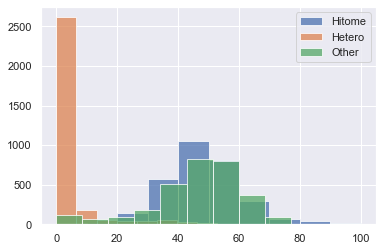

In [5]:
sns.set()
plt.hist(marker_genotype_counts.Homozygous_hitome_per, alpha=0.75, label="Hitome")
plt.hist(marker_genotype_counts.Heterozygous_per, alpha=0.75, label="Hetero")
plt.hist(marker_genotype_counts.Homozygous_parent_per, alpha=0.75, label="Other")
plt.legend()
plt.show()

# Check distrotion of Hitomebore/Donor genotypes

In [6]:
Hitome_SNP_per = []
Hetero_SNP_per = []
others_SNP_per = []
for parent in parent_list:
    Hitome_SNP_per.append(format(marker_genotype_counts[marker_genotype_counts.index.str.contains(parent[:3])].Homozygous_hitome_per.mean(), '.1f') +
                          " ± " + 
                          format(marker_genotype_counts[marker_genotype_counts.index.str.contains(parent[:3])].Homozygous_hitome_per.std(), '.1f'))
    Hetero_SNP_per.append(format(marker_genotype_counts[marker_genotype_counts.index.str.contains(parent[:3])].Heterozygous_per.mean(), '.1f') +
                          " ± " + 
                          format(marker_genotype_counts[marker_genotype_counts.index.str.contains(parent[:3])].Heterozygous_per.std(), '.1f'))
    others_SNP_per.append(format(marker_genotype_counts[marker_genotype_counts.index.str.contains(parent[:3])].Homozygous_parent_per.mean(), '.1f') +
                          " ± " + 
                          format(marker_genotype_counts[marker_genotype_counts.index.str.contains(parent[:3])].Homozygous_parent_per.std(), '.1f'))

In [ ]:
# calculate the segregation distortion
from scipy.stats import chisquare
all_p_values = []
for i in tqdm(range(1,13)):
    tmp_chr = "chr{}".format(str(i).zfill(2))
    genotype = pd.read_csv("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_{}.txt.gz".format(tmp_chr), sep="\t")
    chr_marker_genotype_counts = pd.DataFrame()
    for parent in parent_list:
        pop = parent[:3]
        columns = ["chr", "pos"]
        columns.extend(genotype.columns[genotype.columns.str.contains(pop)])
        fam_genotype = genotype.loc[genotype[parent] == 2, columns].drop(parent, axis=1)
        hitome_ratio = []
        p_values = []
        for j in range(fam_genotype.shape[0]):
            genotype_counts = fam_genotype.iloc[j, 2:]
            hitome = sum(genotype_counts == 0)
#             hetero = sum(genotype_counts == 1)
            others = sum(genotype_counts == 2)
            total = hitome + others
            chi_test = chisquare([hitome, others],
                                 f_exp=[total*0.5, total*0.5]).pvalue
            p_values.append(chi_test)
            hitome_ratio.append(hitome/total)
        all_p_values.append([parent, tmp_chr, fam_genotype.pos.values, hitome_ratio, p_values])
with open('../data/PART0_NAM_stats/segregation_distortion.pic.bin', 'wb') as p:
    pickle.dump(all_p_values, p)

In [7]:
# calc q_values
def calculate_q(p_seq):
    p_arr = np.asarray(p_seq)
    N = len(p_arr)
    idx_arr = np.argsort(p_arr)
    q_arr = p_arr[idx_arr] * N / (np.arange(N) + 1)
    q_arr = np.minimum.accumulate(q_arr[::-1])[::-1]
    q_arr[idx_arr] = q_arr.copy()
    return q_arr

with open('../data/PART0_NAM_stats/segregation_distortion_1to1ratio.pic.bin', 'rb') as p:
    segregation_test = pickle.load(p)
segregation_test = pd.DataFrame(segregation_test)
segregation_test.columns = ["parent", "chr", "pos", "h_ratio", "pvalue"]

distorted_SNP_ratio = []
distorted_hitome_SNP_ratio = []
distorted_others_SNP_ratio = []
for parent in parent_list:
    p = []
    h_ratio = []
    for i, each_chr in enumerate(segregation_test.chr.unique()):
        chr_segregation_test = segregation_test[(segregation_test.parent == parent) & (segregation_test.chr == each_chr)]
        p.extend(chr_segregation_test.pvalue.values[0])
        h_ratio.extend(chr_segregation_test.h_ratio.values[0])
    q = calculate_q(p)
    h_ratio = np.array(h_ratio)
    distorted_SNP_ratio.append(format(sum(q < 0.01) / len(q) * 100, ".2f"))
    distorted_hitome_SNP_ratio.append(format(sum((q < 0.01) & (h_ratio > 0.5)) / len(q) * 100, ".2f"))
    distorted_others_SNP_ratio.append(format(sum((q < 0.01) & (h_ratio < 0.5)) / len(q) * 100, ".2f"))
    print(parent, sum(q < 0.01) / len(q))

N01_KASALATH 0.10253200683425402
N03_KEIBOBA 0.029811540037549555
N04_SHONI 0.1942893355025187
N05_TUPA121-3 0.17934236435090242
N06_SURJAMUKHI 0.07328778298188995
N07_RATUL 0.04891319925948696
N08_BADARI_DHAN 0.030758657231605663
N09_KALUHEENATI 0.2410402738775968
N10_JAGUARY 0.011534479974927108
N11_REXMONT 0.17607018654198245
N12_URASAN 0.025535904568162633
N13_TUPA729 0.0
N14_DEEJIAOHUALUO 0.0035247116700332314
N16_NERICA1 0.11881909202808007
N17_TAKANARI 0.2536516446970679
N18_C8005 0.13731495866100416
N19_MOUKOTOU 0.0
N20_NORTAI 0.04198049959443129
N21_SESIA 0.5530195300111512
N22_HAYAYUKI 0.037260882663051664


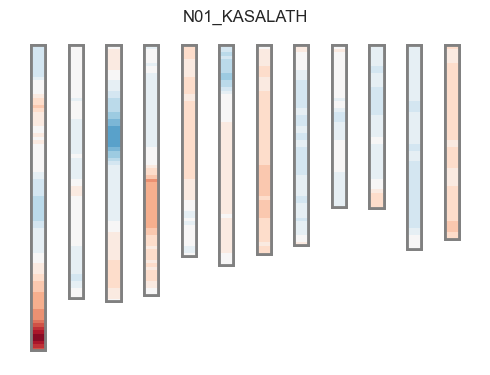

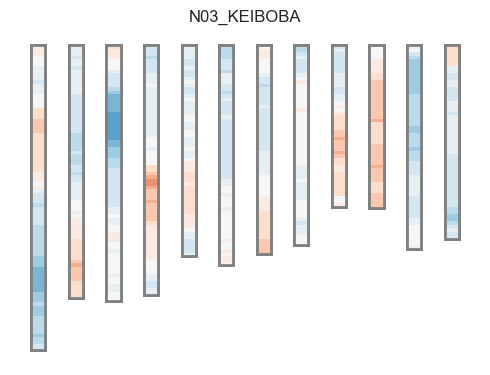

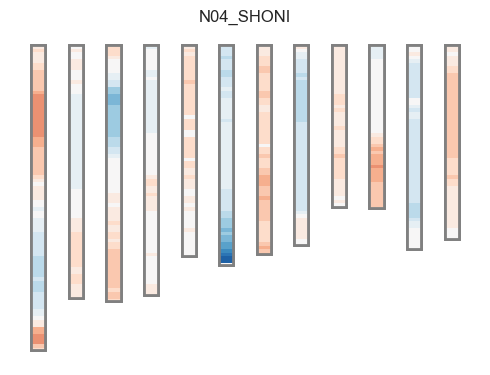

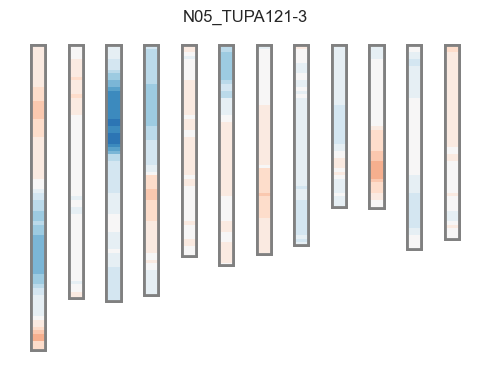

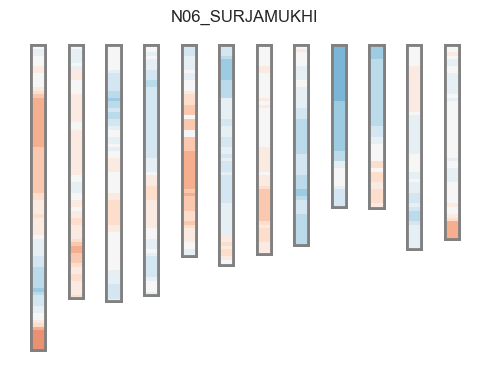

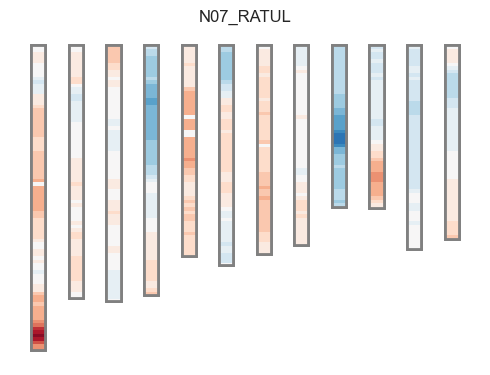

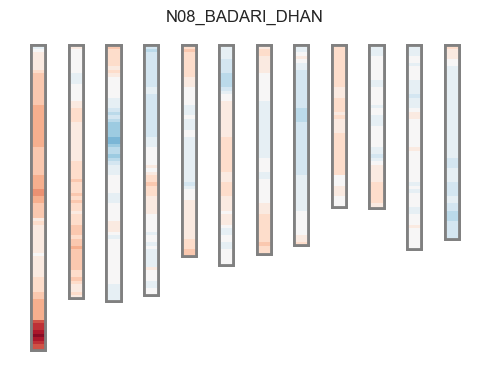

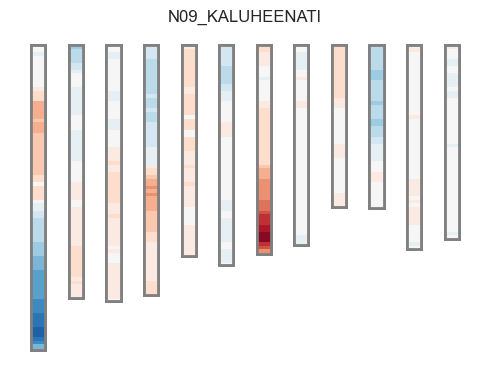

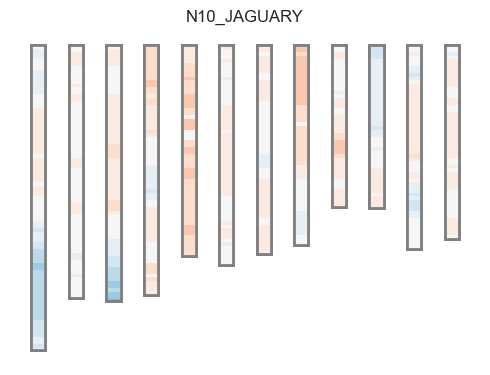

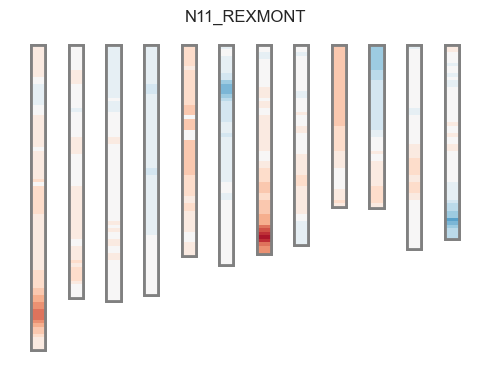

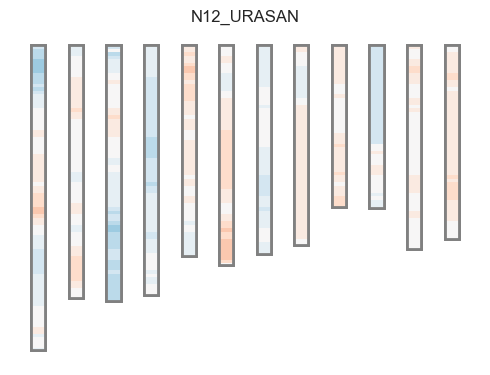

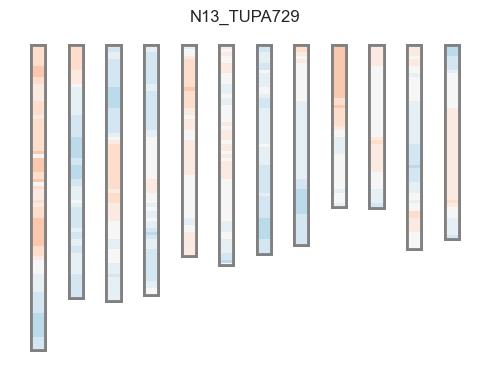

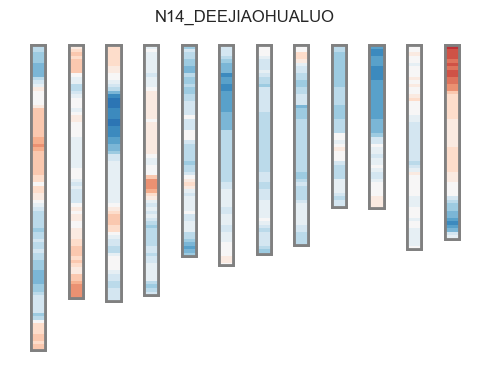

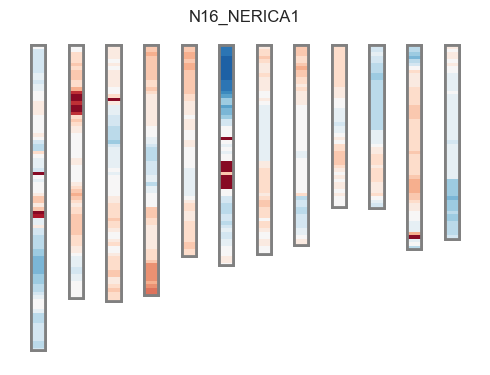

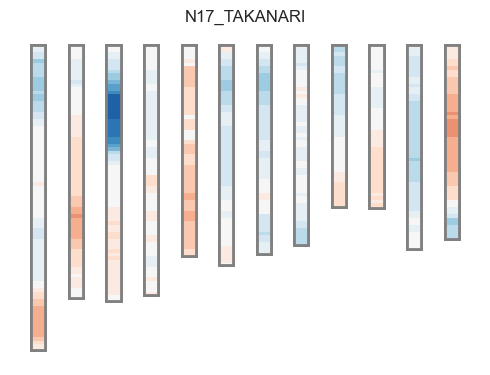

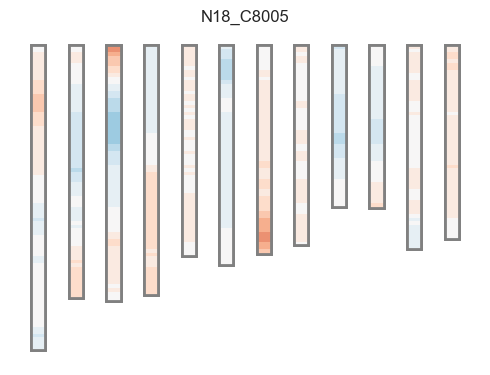

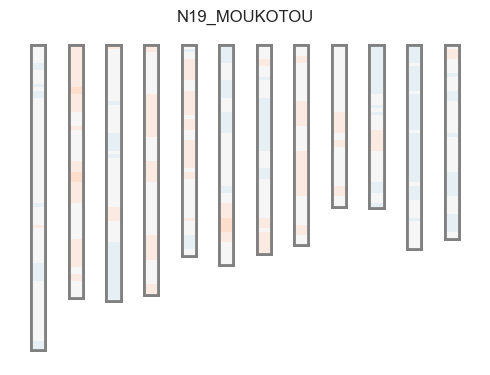

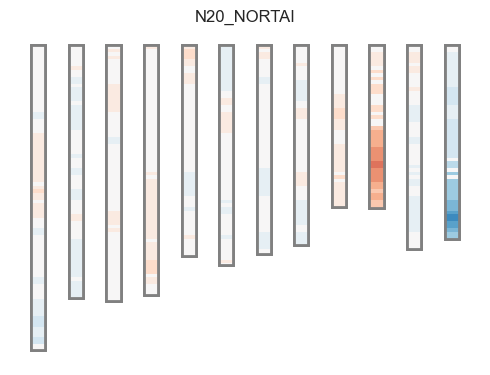

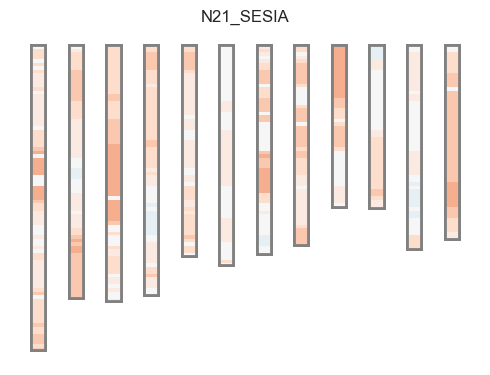

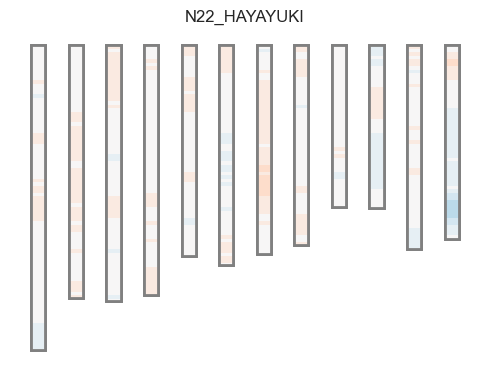

In [8]:
# Visualize distorted genotypes to donor/Hitomebore cultivar
colors = sns.color_palette("RdBu_r", 21)
color_range = np.arange(0, 1.05, 0.05)
chr_length = pd.read_csv("../data/chromosome_length.csv")

for parent in parent_list:
    plt.rcParams['figure.dpi'] = 100
    fig = plt.figure(figsize=(5,12))
    ax = plt.axes()
    
    for i, each_chr in enumerate(chr_length.chr.unique()):
        chr_end = chr_length[chr_length.chr == each_chr].length.values[0]
        r = patches.Rectangle(xy=(i*16000000, 0), width=6000000, height=-chr_end*3, ec='gray', fc="white", linewidth=2)
        ax.add_patch(r)
        
        tmp_segregation_test = segregation_test[(segregation_test.parent == parent) & (segregation_test.chr == each_chr)]
        
        width = 500000
        for start in range(0, chr_end, width):
            end = min(start + width, chr_end)
            pos_ind = (tmp_segregation_test.pos.values[0] > start) & (tmp_segregation_test.pos.values[0] <= end)
            mean_h_ratio = pd.Series(tmp_segregation_test.h_ratio.values[0])[pos_ind].mean()
            if np.isnan(mean_h_ratio):
                mean_h_ratio = 0.5
            color_ind = np.argmin(np.abs(np.array(color_range) - mean_h_ratio))
            r = patches.Rectangle(xy=(i*16000000, -start*3), width=6000000, height=-(end-start)*3, ec='gray', fc=colors[color_ind], linewidth=0)
            ax.add_patch(r)
        r = patches.Rectangle(xy=(i*16000000, 0), width=6000000, height=-chr_end*3, ec='gray', fill=False, linewidth=2)
        ax.add_patch(r)
    
    plt.title(parent)
    plt.axis('scaled')
    plt.axis('off')
    plt.tight_layout()
    ax.set_aspect('equal')
    plt.show()
    

# Stats of recombination events

In [ ]:
def get_recombination_info(genotype, parent, threshold_length):
    
    recombination_info_chr = []
    for ril in genotype.columns[3:]:    
        x = genotype[genotype[parent] != 0].loc[:, ["chr", "pos", ril]].dropna()
        current_set = []
        same_genotype_regions = []
        for idx, i in enumerate(x[ril].values):
            if len(current_set) == 0:
                current_set.append(i)
                each_same_genotype_region = [i, idx]
            else:
                if current_set[0] != i:
                    each_same_genotype_region.append(idx)
                    same_genotype_regions.append(each_same_genotype_region)
                    current_set = [i]
                    each_same_genotype_region = [i, idx]
                else:
                    current_set.append(i)
        each_same_genotype_region.append(idx)
        same_genotype_regions.append(each_same_genotype_region)

        new_same_genotype_regions = []
        recombination_point = []
        for i in same_genotype_regions:
            length = x.iloc[i[1]:i[2], :].pos.max() - x.iloc[i[1]:i[2], :].pos.min()
            if length >= threshold_length:
                if len(new_same_genotype_regions) > 0:
                    if new_same_genotype_regions[-1][0] == i[0]:
                        new_same_genotype_regions[-1] = [i[0],  int(new_same_genotype_regions[-1][1] + length)]
                    else:
                        recombination_point.append(x.iloc[i[1], :].pos)
                        new_same_genotype_regions.append([i[0], length])
                else:
                    new_same_genotype_regions.append([i[0], length])
        recombination_info_chr.append([len(new_same_genotype_regions)-1, new_same_genotype_regions, recombination_point])
    recombination_info_chr = pd.DataFrame(recombination_info_chr)
    recombination_info_chr.columns = ["count", "same_genotype_regions", "recombination_point"]

    return recombination_info_chr


recombination_info = pd.DataFrame()
parent_list = pd.read_csv("../data/family_list.csv").family.unique()
for parent in tqdm(parent_list):
    pop = parent[:3]
    for i in range(1,13):
        tmp_chr = "chr{}".format(str(i).zfill(2))
        genotype = pd.read_csv("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_{}.txt.gz".format(tmp_chr), sep="\t")
        columns = ["chr", "pos"]
        columns.extend(genotype.columns[genotype.columns.str.contains(pop)])
        genotype = genotype.loc[:, columns]
        recombination_info_chr = get_recombination_info(genotype, parent, 500000)
        recombination_info_chr["chromosome"] = tmp_chr
        recombination_info = pd.concat([recombination_info, recombination_info_chr], axis=0)

id_family_list = pd.DataFrame()
family_list = pd.read_csv("../data/family_list.csv")
for family in family_list.family.unique():
    for i in range(12):
        id_family_list = pd.concat([id_family_list, family_list[family_list["family"] == family]], axis=0)

recombination_info = pd.concat([recombination_info.reset_index(drop=True), id_family_list.reset_index(drop=True)], axis=1)
with open('../data/PART0_NAM_stats/recombination_stats_500kbp.pic.bin', 'wb') as p:
    pickle.dump(recombination_info, p)

In [4]:
with open('../data/PART0_NAM_stats/recombination_stats_500kbp.pic.bin', 'rb') as p:
    recombination_info = pickle.load(p)

NA_contain_RILs = recombination_info[recombination_info["count"] == -1].id.unique()
recombination_info = recombination_info[~recombination_info.id.isin(NA_contain_RILs)]
recombination_info

,count,same_genotype_regions,recombination_point,chromosome,id,family
0,3,"[[0.0, 27130326], [2.0, 4440886], [0.0, 101417...","[27778880, 32233078, 42377009]",chr01,N01_001,N01_KASALATH
1,3,"[[2.0, 4743440], [0.0, 13422814], [2.0, 136974...","[4961340, 18422625, 32153800]",chr01,N01_002,N01_KASALATH
2,2,"[[0, 695658], [2, 25342328], [0, 16705813]]","[927375, 26537878]",chr01,N01_003,N01_KASALATH
3,3,"[[2.0, 4681766], [0.0, 9940825], [2.0, 2589687...","[4880813, 14856482, 40772672]",chr01,N01_004,N01_KASALATH
4,3,"[[2.0, 6675501], [0.0, 16553406], [2.0, 100563...","[6854589, 23663072, 33749866]",chr01,N01_005,N01_KASALATH
...,...,...,...,...,...,...
36523,3,"[[2.0, 6966265], [0.0, 973551], [2.0, 15985206...","[8322037, 9363085, 26190554]",chr12,N22_244,N22_HAYAYUKI
36524,1,"[[0.0, 6303808], [2.0, 19461673]]",[7502115],chr12,N22_245,N22_HAYAYUKI
36525,1,"[[2, 25550694], [0, 624250]]",[26853650],chr12,N22_248,N22_HAYAYUKI
36526,0,"[[0, 26365799]]",[],chr12,N22_249,N22_HAYAYUKI


In [7]:
# Calculate approximate Hitomebore genotype % for each RIL
Hitome_per = []
for RIL in recombination_info.id.unique():
    tmp_recombination_info = recombination_info[recombination_info.id == RIL]
    Hitome_len = 0
    Total_len = 0
    for each_chr in tmp_recombination_info.same_genotype_regions.values:
        for each_region in each_chr:
            if each_region[0] == 0:
                Hitome_len+=each_region[1]*2
            elif each_region[0] == 1:
                Hitome_len+=each_region[1]
            Total_len+=each_region[1]*2
    Hitome_per.append([RIL, Hitome_len/Total_len])
Hitome_per = pd.DataFrame(Hitome_per)
Hitome_per.columns = ["RIL", "Hitomebore_per"]
Hitome_per.to_csv("../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv", index=None)

total 27.134475939353987 7.376706859695715
N01_KASALATH 27.27485380116959 8.774321448993357
N03_KEIBOBA 26.350649350649352 8.151148181579009
N04_SHONI 22.176 6.67815891182689
N05_TUPA121-3 24.143564356435643 5.599767511904394
N06_SURJAMUKHI 27.0 5.986651818838307
N07_RATUL 22.359375 5.229243738760422
N08_BADARI_DHAN 24.20253164556962 6.902953189713106
N09_KALUHEENATI 24.753036437246962 8.632971212860701
N10_JAGUARY 28.776978417266186 8.631794249360844
N11_REXMONT 27.759358288770052 6.384697398962251
N12_URASAN 28.26241134751773 7.142073918558673
N13_TUPA729 24.558139534883722 6.527056180262352
N14_DEEJIAOHUALUO 26.88888888888889 5.472542183365785
N16_NERICA1 29.94736842105263 7.856645898824533
N17_TAKANARI 26.47482014388489 7.661621782428481
N18_C8005 26.416 6.442434621742132
N19_MOUKOTOU 30.180722891566266 5.6770858998283895
N20_NORTAI 28.061475409836067 6.015780984998967
N21_SESIA 29.288 8.452861020846788
N22_HAYAYUKI 30.267489711934157 5.634021936108042


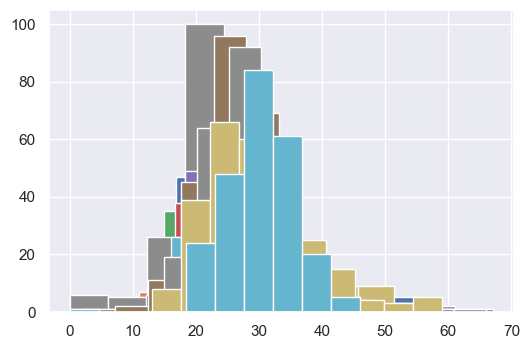

In [10]:
total_count = recombination_info.groupby("id").sum()["count"]
print("total", total_count.mean(), total_count.std())
recombination_counts = []
for family in recombination_info.family.unique():
    total_count = recombination_info[recombination_info.family == family].groupby("id").sum()["count"]
    recombination_counts.append(format(total_count.mean(), ".1f") + " ± " + format(total_count.std(), ".1f"))
    print(family, total_count.mean(), total_count.std())
    plt.hist(total_count.values, label=family)
# plt.legend()
plt.show()

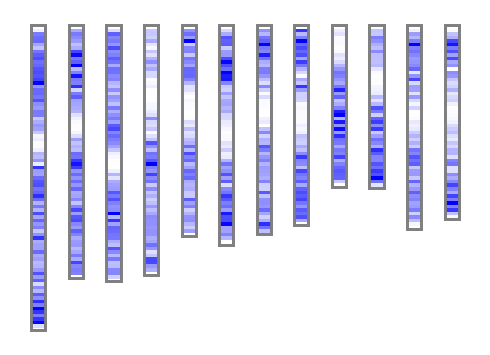

In [219]:
chr_length = pd.read_csv("../data/chromosome_length.csv")
plt.rcParams['figure.dpi'] = 100
fig = plt.figure(figsize=(5,12))
ax = plt.axes()
for i, each_chr in enumerate(chr_length.chr.unique()):
    chr_end = chr_length[chr_length.chr == each_chr].length.values[0]
    r = patches.Rectangle(xy=(i*16000000, 0), width=6000000, height=-chr_end*3, ec='gray', fc="white", linewidth=2)
    ax.add_patch(r)
    
    recombination_info_chr = recombination_info[recombination_info["chromosome"] == each_chr]
    recombination_points = []
    for j in recombination_info_chr.recombination_point.values:
        recombination_points.extend(j)
    recombination_points = np.array(recombination_points)
    recombination_points_windows = []
    window_width = 500000
    sliding_width = 500000
    max_count = 0
    for start in range(0, chr_end, sliding_width):
        end = min(start + window_width, chr_end)
        max_count = max(max_count, sum((recombination_points >= start) & (recombination_points <= end)))
    for start in range(0, chr_end, sliding_width):
        end = min(start + window_width, chr_end)
        color_level = sum((recombination_points >= start) & (recombination_points <= end)) / max_count
        r = patches.Rectangle(xy=(i*16000000, -start*3), width=6000000, height=-(end-start)*3, ec='gray', fc=(0, 0, 1, color_level), linewidth=0)
        ax.add_patch(r)
    r = patches.Rectangle(xy=(i*16000000, 0), width=6000000, height=-chr_end*3, ec='gray', fill=False, linewidth=2)
    ax.add_patch(r)

plt.axis('scaled')
plt.axis('off')
plt.tight_layout()
ax.set_aspect('equal')

plt.show()

In [ ]:
chr_length = pd.read_csv("../data/chromosome_length.csv")
for chrom in recombination_info.chromosome.unique():
    recombination_info_chr = recombination_info[recombination_info["chromosome"] == chrom]
    plt.figure(figsize=(20,5))
    for family in recombination_info_chr.family.unique():
        recombination_info_chr_fam = recombination_info_chr[recombination_info_chr["family"] == family]
        recombination_points = []
        for i in recombination_info_chr_fam.recombination_point.values:
            recombination_points.extend(i)
        recombination_points = np.array(recombination_points)
        recombination_points_windows = []
        window_width = 500000
        sliding_width = 100000
        for i in range(0, chr_length[chr_length.chr == chrom].length.values[0], sliding_width):
            recombination_points_windows.append(sum((recombination_points >= i) & (recombination_points <= i + window_width)))
        plt.bar(x=range(len(recombination_points_windows)), height=recombination_points_windows, linewidth=0)
    plt.show()
    plt.clf()

# Summarize NAM stats

In [11]:
NAM_stats = pd.read_csv("../data/Founders.csv").sort_values(by="ID")
NAM_stats.index = NAM_stats["ID"] + "_" + NAM_stats["Founder"]
NAM_stats["Common_parent"] = "Hitomebore"
NAM_stats.columns = ["pop_ID", "Founder", "group", "Number_of_lines", "Generation", "Common_parent"]
NAM_stats = NAM_stats.loc[:, ["pop_ID", "Common_parent", "Founder", "group", "Number_of_lines", "Generation"]]
NAM_stats.head()

NAM_stats = NAM_stats.join(parent_marker_stats)
NAM_stats["Hitomebore_genotype_SNP(%)"] = Hitome_SNP_per
NAM_stats["Founder_genotype_SNP(%)"] = others_SNP_per
NAM_stats["Heterozygous_genotype_SNP(%)"] = Hetero_SNP_per
NAM_stats["Segregation_distorted_SNP(%)"] = distorted_SNP_ratio
NAM_stats["Segregation_distorted_toHitomebore_SNP(%)"] = distorted_hitome_SNP_ratio
NAM_stats["Segregation_distorted_toFounder_SNP(%)"] = distorted_others_SNP_ratio
NAM_stats["Number_of_Recombination"] = recombination_counts
NAM_stats.to_csv("../data/PART0_NAM_stats/NAM_stats.csv")
NAM_stats

,pop_ID,Common_parent,Founder,group,Number_of_lines,Generation,Number_of_SNPs,Hitomebore_genotype_SNP(%),Founder_genotype_SNP(%),Heterozygous_genotype_SNP(%),Segregation_distorted_SNP(%),Segregation_distorted_toHitomebore_SNP(%),Segregation_distorted_toFounder_SNP(%),Number_of_Recombination
N01_KASALATH,N01,Hitomebore,KASALATH,aus,170,F9,1044152,46.6 ± 11.1,46.7 ± 14.3,5.1 ± 10.7,10.25,5.41,4.84,27.3 ± 8.8
N03_KEIBOBA,N03,Hitomebore,KEIBOBA,indica,79,F9,968853,44.9 ± 9.6,49.9 ± 13.3,3.4 ± 9.1,2.98,0.36,2.62,26.4 ± 8.2
N04_SHONI,N04,Hitomebore,SHONI,aus,123,F9,1020967,49.4 ± 11.1,46.0 ± 14.9,3.6 ± 9.3,19.43,12.89,6.54,22.2 ± 6.7
N05_TUPA121-3,N05,Hitomebore,TUPA121-3,aus,204,F9,979144,46.5 ± 9.9,50.6 ± 11.1,2.1 ± 7.2,17.93,5.09,12.85,24.1 ± 5.6
N06_SURJAMUKHI,N06,Hitomebore,SURJAMUKHI,aus,74,F9,1005188,45.3 ± 10.8,47.7 ± 14.0,3.9 ± 8.4,7.33,2.61,4.72,27.0 ± 6.0
N07_RATUL,N07,Hitomebore,RATUL,aus,64,F9,1011731,48.8 ± 10.4,47.8 ± 12.6,2.7 ± 8.2,4.89,1.07,3.82,22.4 ± 5.2
N08_BADARI_DHAN,N08,Hitomebore,BADARI_DHAN,aus,80,F9,1041788,50.2 ± 11.4,46.3 ± 14.8,2.8 ± 8.5,3.08,2.58,0.50,24.2 ± 6.9
N09_KALUHEENATI,N09,Hitomebore,KALUHEENATI,aus,237,F9,971821,48.3 ± 12.3,44.9 ± 17.7,4.4 ± 10.5,24.10,11.86,12.24,24.8 ± 8.6
N10_JAGUARY,N10,Hitomebore,JAGUARY,tropical-japonica,140,F9,210586,46.3 ± 16.4,43.1 ± 17.3,5.4 ± 11.6,1.15,0.05,1.11,28.8 ± 8.6
N11_REXMONT,N11,Hitomebore,REXMONT,tropical-japonica,187,F9,309689,50.2 ± 10.7,48.0 ± 11.3,1.2 ± 4.4,17.61,12.09,5.52,27.8 ± 6.4
